# Plotting satellite imagery showing possible crevasse-squeeze ridges adjacent to Kotick Glacier
This notebook: 
- loads geotiffs that we previously clipped and pansharpened in QGIS
- applies a gamma stretch and a percetnile stretch, 
- plots them at two different zoom levels, and
- saves the results. 

In [ ]:
import rioxarray
import matplotlib.pyplot as plt

In [4]:
panel_a_fn = '/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/worldview/kotick/processed_images/2015_clipped.tif'
panel_b_fn = '/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/worldview/kotick/processed_images/2019_pan.tif'
panel_c_fn = '/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/worldview/kotick/processed_images/2025_pan.tif'
files = [panel_a_fn, panel_b_fn, panel_c_fn]

In [ ]:
def stretch(rgb , gamma = 0.1, top_percentile = 0.95, bottom_percentile = 0.05, percentile_clip = None):
    if percentile_clip is not None:
        top_percentile = 1-percentile_clip
        bottom_percentile = percentile_clip
    
    p_top = rgb.quantile(top_percentile, dim = ['x', 'y'])
    p_bottom = rgb.quantile(bottom_percentile, dim = ['x', 'y'])

    stretched = (rgb - p_bottom) / (p_top - p_bottom)
    stretched = stretched.clip(min=0, max=1)
    bright = stretched ** gamma
    return bright


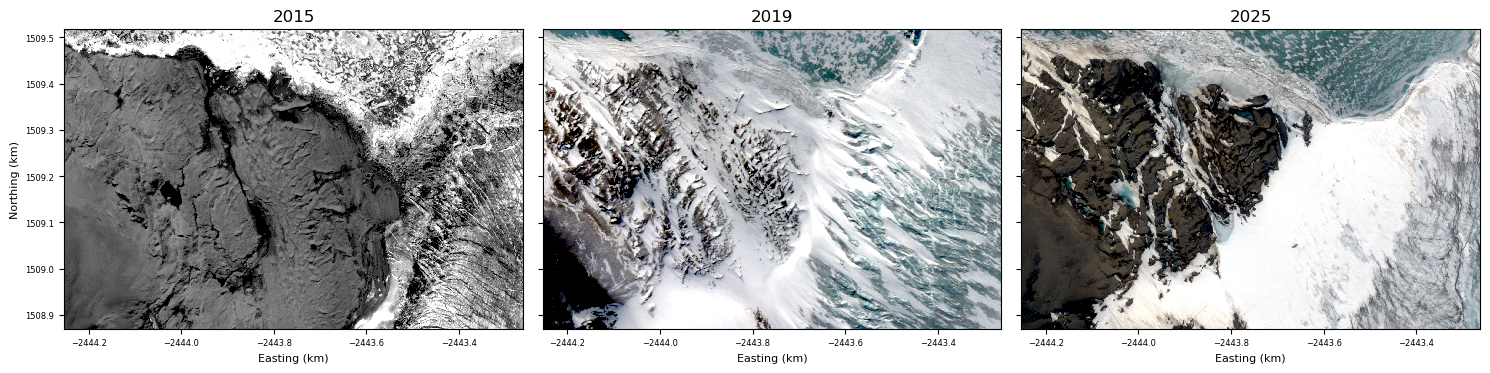

In [ ]:
def three_panel_plot(bounds =[-2444252.974,  1508870.895,  -2443262.496, 1509516.983]):     # same as original qgis version
# def three_panel_plot(bounds = [-2444806.6159,-2442954.1432,1508585.2026,1509752.3886]):   # original bounds

    images  = [rioxarray.open_rasterio(file, masked=True, chunks = "auto").rio.clip_box(*bounds) for file in files]
    images_km = [image.assign_coords(x=image.x / 1000, y=image.y / 1000) for image in images]

    fig, ax = plt.subplots(1,3, figsize=(15, 5) )

    stretch_settings = {'gamma': 0.5, 'percentile_clip': 0.05}

    stretch(images_km[0].squeeze(), **stretch_settings).plot.imshow(ax=ax[0], add_colorbar=False, cmap = 'gray');
    stretch(images_km[1].isel(band =[0, 1, 2]), **stretch_settings).plot.imshow(ax=ax[1]);
    stretch(images_km[2].isel(band =[4, 2, 1]), **stretch_settings).plot.imshow(ax=ax[2]);

    ax[0].ticklabel_format(style='plain', useOffset=False)
    ax[1].ticklabel_format(style='plain', useOffset=False)
    ax[2].ticklabel_format(style='plain', useOffset=False)

    ax[0].set_aspect('equal') ;
    ax[1].set_aspect('equal') ;
    ax[2].set_aspect('equal') ;
    ax[0].set_title('2015');
    ax[1].set_title('2019');
    ax[2].set_title('2025');

    ax[1].set_ylabel('');
    ax[2].set_ylabel('');
    ax[1].set_yticklabels([]);
    ax[2].set_yticklabels([]);

    tickfontsize = 6
    ax[0].tick_params(axis='both', labelsize=tickfontsize)
    ax[1].tick_params(axis='both', labelsize=tickfontsize)
    ax[2].tick_params(axis='both', labelsize=tickfontsize)

    labelsize = 8
    ax[0].set_xlabel('Easting (km)', fontsize=labelsize)
    ax[0].set_ylabel('Northing (km)', fontsize=labelsize)
    ax[1].set_xlabel('Easting (km)', fontsize=labelsize)
    ax[2].set_xlabel('Easting (km)', fontsize=labelsize)

    plt.tight_layout()
    plt.show()

    return fig, ax, stretch_settings

fig, ax, stretch_settings= three_panel_plot()  
fig.savefig(f'kotick_midzoom_gamma{stretch_settings['gamma']}_stretch{stretch_settings['percentile_clip']}.pdf', dpi=300)

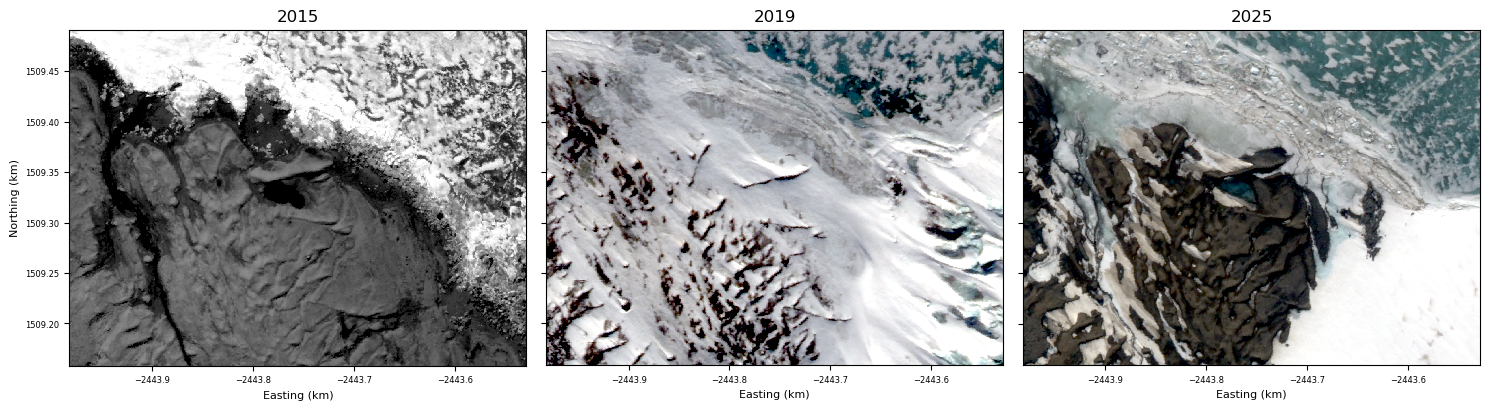

In [36]:
fig, ax, stretch_settings = three_panel_plot(bounds = [-2443981.574638835,1509158.6544842897,-2443529.0073669488,1509490.9864072972])  
fig.savefig(f'kotick_closezoom_gamma{stretch_settings['gamma']}_stretch{stretch_settings['percentile_clip']}.pdf', dpi=300)